In [2]:
import os

files = os.listdir("FingeringFiles")
print(f"sum files: {len(files)}")

sum files: 309


In [3]:
import pandas as pd

columns = [
    "note_id", "onset_time", "offset_time", "spelled_pitch",
    "onset_velocity", "offset_velocity", "channel", "finger_number"
]

In [4]:
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import music21
import torch
from torch.utils.data import Dataset
import pandas as pd
import glob

In [5]:
sample_file = "FingeringFiles/001-1_fingering.txt"

df_sample = pd.read_csv(
    sample_file, 
    sep=r"\s+", #bu regex o verisetindeki boşlukve tabları  ayarlıyor
    comment="/", 
    header=None, 
    names=columns
)

df_sample.head()

,note_id,onset_time,offset_time,spelled_pitch,onset_velocity,offset_velocity,channel,finger_number
0,0,0.156289,0.302811,C4,64,80,0,1
1,1,0.312579,0.459100,D4,64,80,0,2
2,2,0.468869,0.615390,E4,64,80,0,3
3,3,0.625158,0.771679,F4,64,80,0,4
4,4,0.781447,0.927969,D4,64,80,0,2


In [6]:
df_list = pd.read_csv("List.csv")

composer_counts = df_list["Composer"].value_counts()

print(f"eser sayısı: {len(df_list)}")
print(composer_counts)

eser sayısı: 150
Composer
Chopin          23
Bach            22
Beethoven       21
Mozart          20
Grieg           10
Debussy          9
Schumann         6
Schubert         5
Rachmaninoff     4
Ravel            3
Mussorgsky       3
Liszt            3
Brahms           3
Joplin           3
Mendelssohn      3
Faure            2
Satie            2
Scriabin         2
Dvorak           1
Tchaikovsky      1
Scarlatti        1
Saint-Saens      1
Bartok           1
Albeniz          1
Name: count, dtype: int64


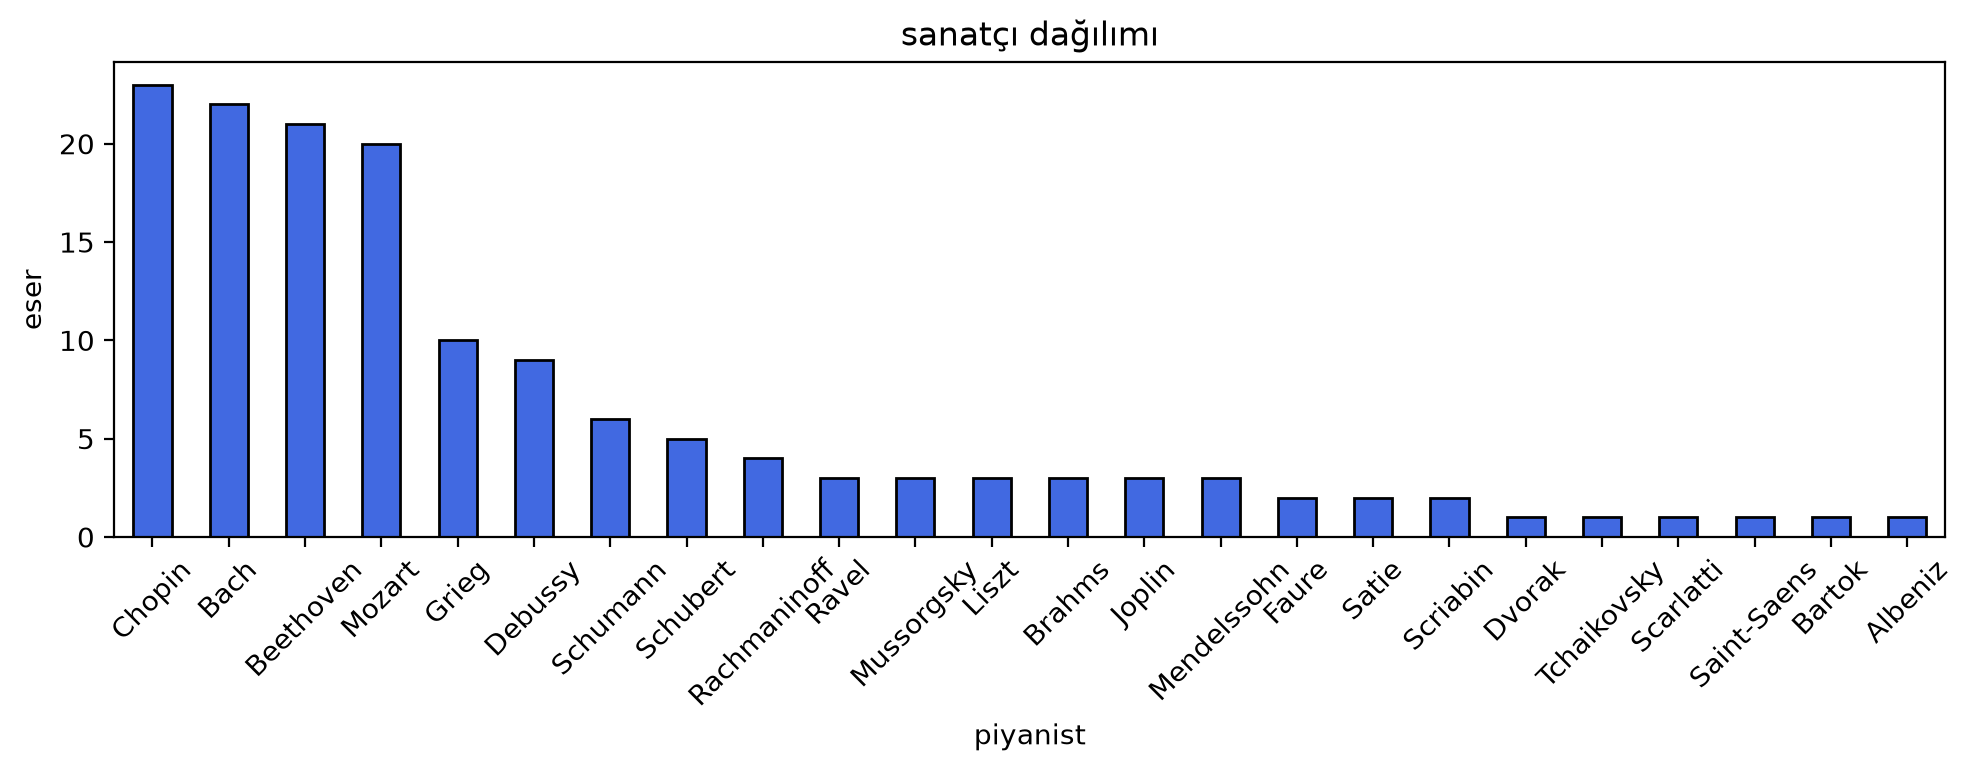

In [7]:
plt.figure(figsize=(10, 4))
composer_counts.plot(kind="bar", color="royalblue", edgecolor="black")
plt.title("sanatçı dağılımı")
plt.xlabel("piyanist")
plt.ylabel("eser")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
df_sample["finger_clean"] = df_sample["finger_number"].astype(str).apply(lambda x: x.split("_")[0])
df_sample["finger"] = df_sample["finger_clean"].astype(int)
df_sample["midi_pitch"] = df_sample["spelled_pitch"].apply(lambda p: music21.pitch.Pitch(p).midi)
df_sample[["onset_time", "spelled_pitch", "midi_pitch", "channel", "finger"]].head()

,onset_time,spelled_pitch,midi_pitch,channel,finger
0,0.156289,C4,60,0,1
1,0.312579,D4,62,0,2
2,0.468869,E4,64,0,3
3,0.625158,F4,65,0,4
4,0.781447,D4,62,0,2


In [19]:
all_files = glob.glob(os.path.join("FingeringFiles", "*_fingering.txt"))

records = []
for file_path in all_files:
    df_temp = pd.read_csv(file_path, sep=r"\s+", comment="/", header=None, usecols=[6, 7])
    records.append(df_temp)

all_fingers_df = pd.concat(records, ignore_index=True)
all_fingers_df.columns = ["channel", "finger_number"]
total_notes = len(all_fingers_df)
substitution_mask = all_fingers_df["finger_number"].astype(str).str.contains("_")
substitution_count = substitution_mask.sum()
normal_count = total_notes - substitution_count
substitution_ratio = (substitution_count / total_notes) * 100
print(f"okunan dosya sayısı: {len(records)} / {len(all_files)}")
print(f"okunan nota sayısı: {total_notes:,}")
print(f"Normal Fingering: {normal_count:,}")
print(f"Finger Substitution İçeren Nota: {substitution_count:,}")
print(f"Substitution Oranı: %{substitution_ratio:.2f}")
all_fingers_df.head()

okunan dosya sayısı: 309 / 309
okunan nota sayısı: 100,040
Normal Fingering: 99,716
Finger Substitution İçeren Nota: 324
Substitution Oranı: %0.32


,channel,finger_number
0,0,1
1,0,2
2,0,3
3,0,4
4,0,2


In [10]:
all_fingers_df["finger_clean"] = (
    all_fingers_df["finger_number"]
    .astype(str)
    .apply(lambda x: x.split("_")[0])
)

all_fingers_df["finger"] = pd.to_numeric(all_fingers_df["finger_clean"], errors="coerce")
all_fingers_df = all_fingers_df.dropna(subset=["finger"]).copy()
all_fingers_df["finger"] = all_fingers_df["finger"].astype(int)

right_hand_counts = (
    all_fingers_df[all_fingers_df["channel"] == 0]["finger"]
    .value_counts()
    .sort_index()
)

left_hand_counts = (
    all_fingers_df[all_fingers_df["channel"] == 1]["finger"]
 .abs()   
    .value_counts()
    .sort_index()
)

print("sağ el parmak sayıları")
print(right_hand_counts)

print("\nsol el parmak sayıları")
print(left_hand_counts)

sağ el parmak sayıları
finger
1    14396
2    12972
3    10757
4     7807
5     8307
Name: count, dtype: int64

sol el parmak sayıları
finger
1    14654
2     9653
3     6585
4     4708
5    10201
Name: count, dtype: int64


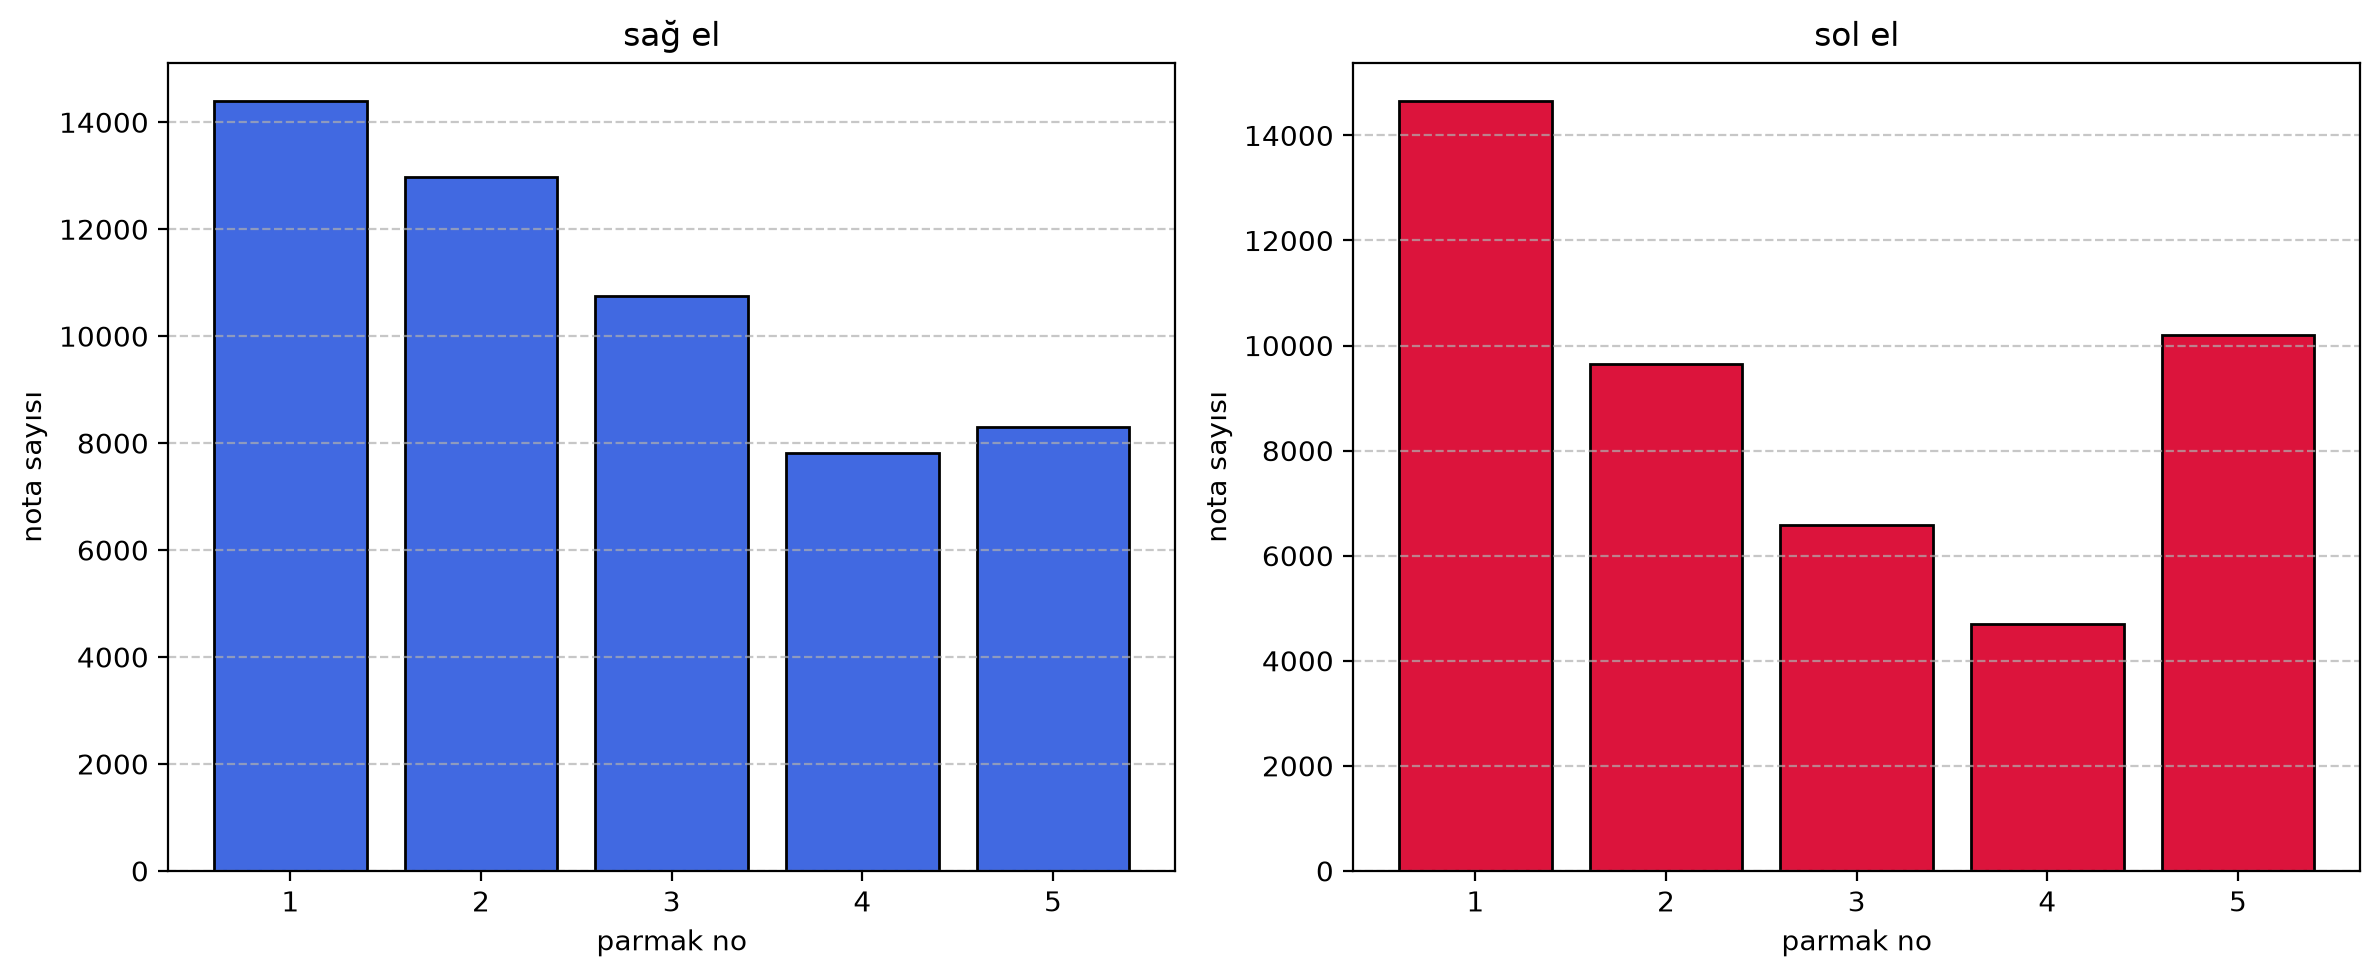

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(right_hand_counts.index, right_hand_counts.values, color="royalblue", edgecolor="black")
axes[0].set_title("sağ el")
axes[0].set_xlabel("parmak no")
axes[0].set_ylabel("nota sayısı")
axes[0].set_xticks(range(1, 6))
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

axes[1].bar(left_hand_counts.index, left_hand_counts.values, color="crimson", edgecolor="black")
axes[1].set_title("sol el")
axes[1].set_xlabel("parmak no")
axes[1].set_ylabel("nota sayısı")
axes[1].set_xticks(range(1, 6))
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
piece_ids = sorted(list(set([os.path.basename(f).split("-")[0] for f in all_files])))
print(f"Toplam farklı eser sayısı: {len(piece_ids)}")

random.seed(59)
shuffled_pieces = piece_ids.copy()
random.shuffle(shuffled_pieces)
#validation eklendi
train_idx = int(len(shuffled_pieces) * 0.70)
val_idx = int(len(shuffled_pieces) * 0.85)

train_pieces = set(shuffled_pieces[:train_idx])
val_pieces = set(shuffled_pieces[train_idx:val_idx])
test_pieces = set(shuffled_pieces[val_idx:])

train_files = [f for f in all_files if os.path.basename(f).split("-")[0] in train_pieces]
val_files = [f for f in all_files if os.path.basename(f).split("-")[0] in val_pieces]
test_files = [f for f in all_files if os.path.basename(f).split("-")[0] in test_pieces]

print(f"Traindeki eserler: {len(train_pieces)} | İlgili Dosya Sayısı: {len(train_files)}")
print(f"Validation'daki eserler: {len(val_pieces)} | İlgili Dosya Sayısı: {len(val_files)}")
print(f"Testteki eserler: {len(test_pieces)} | İlgili Dosya Sayısı: {len(test_files)}")

Toplam farklı eser sayısı: 150
Traindeki eserler: 105 | İlgili Dosya Sayısı: 208
Validation'daki eserler: 22 | İlgili Dosya Sayısı: 46
Testteki eserler: 23 | İlgili Dosya Sayısı: 55


In [ ]:
class PianoSequenceDataset(Dataset):
    def __init__(self, file_list, sequence_length=64, feature_stats=None, verbose=True):
        self.sequence_length = sequence_length
        self.inputs = []
        self.target_hands = []
        self.target_fingers = []
        
        total_raw_rows = 0
        total_cleaned_rows = 0
        
        for file_path in file_list:
            df = pd.read_csv(file_path, sep=r"\s+", comment="/", header=None,
                             names=["note_id", "onset_time", "offset_time", "spelled_pitch",
                                    "onset_velocity", "offset_velocity", "channel", "finger_number"])
            
            total_raw_rows += len(df)
            
            df["finger_clean"] = df["finger_number"].astype(str).apply(lambda x: x.split("_")[0])
            
            # Geçici olarak işaretiyle birlikte numeric'e çeviriyoruz
            df["finger_signed"] = pd.to_numeric(df["finger_clean"], errors="coerce")
            df = df.dropna(subset=["finger_signed", "onset_time", "offset_time"]).copy()
            
            # --- YENİ EKLENEN TUTARLILIK KONTROLÜ (CONSISTENCY CHECK) ---
            # Sağ el (channel == 0) ise finger_signed pozitif (> 0) olmalı
            right_hand_valid = (df["channel"] == 0) & (df["finger_signed"] > 0)
            
            # Sol el (channel == 1) ise finger_signed negatif (< 0) olmalı
            left_hand_valid = (df["channel"] == 1) & (df["finger_signed"] < 0)
            
            # Bütün satırlar ya sağ el ya da sol el kuralına uymak ZORUNDA!
            assert (right_hand_valid | left_hand_valid).all(), f"Kritik Veri Hatası ({file_path}): El (channel) ve parmak işareti (sign) uyuşmazlığı saptandı!"
            
            # Güvenlik testini başarıyla geçtikten sonra işareti kaldırıp (abs) 1-5 formatına çekebiliriz
            df["finger"] = df["finger_signed"].astype(int).abs()
            
            total_cleaned_rows += len(df)
            
            df["midi_pitch"] = df["spelled_pitch"].apply(lambda p: music21.pitch.Pitch(p).midi)
            df = df.sort_values(by="onset_time").reset_index(drop=True)

            df["duration"] = df["offset_time"] - df["onset_time"]
            df["onset_diff"] = df["onset_time"].diff().fillna(0.0)

            assert df["channel"].isin([0, 1]).all(), f"Hata ({file_path}): Geçersiz el (channel) bilgisi!"
            assert df["finger"].isin([1, 2, 3, 4, 5]).all(), f"Hata ({file_path}): 1-5 aralığı dışında parmak var!"
            assert (df["duration"] >= 0).all(), f"Hata ({file_path}): Negatif nota süresi (duration) bulundu!"
            assert np.isfinite(df["midi_pitch"]).all(), f"Hata ({file_path}): Bozuk MIDI pitch verisi saptandı!"

            X_features = df[["midi_pitch", "duration", "onset_diff"]].values

            if feature_stats is not None:
                X_features = (X_features - feature_stats['mean']) / feature_stats['std']
                
            Y_hand = df["channel"].values
            Y_finger = df["finger"].values - 1 
            
            for i in range(0,
                            len(df) - sequence_length + 1,
                              sequence_length):
                self.inputs.append(X_features[i : i + sequence_length])
                self.target_hands.append(Y_hand[i : i + sequence_length])
                self.target_fingers.append(Y_finger[i : i + sequence_length])
            
        print(f"--- VERİ TEMİZLİK VE FİLTRELEME RAPORU ---")
        print(f"Temizlik Öncesi Toplam Ham Satır: {total_raw_rows:,}")
        print(f"Temizlik Sonrası Kalan Net Satır: {total_cleaned_rows:,}")
        print(f"Ayıklanan / Silinen Gürültülü Satır: {total_raw_rows - total_cleaned_rows:,}\n")
                
        self.inputs = torch.tensor(np.array(self.inputs), dtype=torch.float32)
        self.target_hands = torch.tensor(np.array(self.target_hands), dtype=torch.long)
        self.target_fingers = torch.tensor(np.array(self.target_fingers), dtype=torch.long)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        x = torch.tensor(self.inputs[idx], dtype=torch.float32)
        y_hand = torch.tensor(self.target_hands[idx], dtype=torch.long)
        y_finger = torch.tensor(self.target_fingers[idx], dtype=torch.long)
        return x, y_hand, y_finger

In [21]:
def get_train_stats(file_list):
    all_features = []
    print("Eğitim seti üzerinden normalizasyon istatistikleri hesaplanıyor...")
    for file_path in file_list:
        df = pd.read_csv(file_path, sep=r"\s+", comment="/", header=None,
                         names=["note_id", "onset_time", "offset_time", "spelled_pitch",
                                "onset_velocity", "offset_velocity", "channel", "finger_number"])
        
        df["finger_clean"] = df["finger_number"].astype(str).apply(lambda x: x.split("_")[0])
        df["finger"] = pd.to_numeric(df["finger_clean"], errors="coerce")
        df = df.dropna(subset=["finger", "onset_time", "offset_time"]).copy()
        
        df["midi_pitch"] = df["spelled_pitch"].apply(lambda p: music21.pitch.Pitch(p).midi)
        df = df.sort_values(by="onset_time").reset_index(drop=True)
        df["duration"] = df["offset_time"] - df["onset_time"]
        df["onset_diff"] = df["onset_time"].diff().fillna(0.0)
        
        X = df[["midi_pitch", "duration", "onset_diff"]].values
        all_features.append(X)
        
    all_features = np.vstack(all_features)
    stats = {
        'mean': np.mean(all_features, axis=0),
        # 1e-8 eklememizin sebebi sıfıra bölme hatasını önlemektir
        'std': np.std(all_features, axis=0) + 1e-8 
    }
    return stats

train_stats = get_train_stats(train_files)
print(f"Hesaplanan Ortalama (Mean): {train_stats['mean']}")
print(f"Hesaplanan Standart Sapma (Std): {train_stats['std']}\n")

train_dataset = PianoSequenceDataset(train_files, sequence_length=64, feature_stats=train_stats)
val_dataset = PianoSequenceDataset(val_files, sequence_length=64, feature_stats=train_stats)
test_dataset = PianoSequenceDataset(test_files, sequence_length=64, feature_stats=train_stats)

print(f"Eğitim (Train) Paket Sayısı: {len(train_dataset)}")
print(f"Doğrulama (Validation) Paket Sayısı: {len(val_dataset)}")
print(f"Test Paket Sayısı: {len(test_dataset)}")
print(f"Toplam Paket Sayısı: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")

Eğitim seti üzerinden normalizasyon istatistikleri hesaplanıyor...
Hesaplanan Ortalama (Mean): [63.68299363  0.32805711  0.11541683]
Hesaplanan Standart Sapma (Std): [11.67267101  0.36669458  0.16171741]

--- VERİ TEMİZLİK VE FİLTRELEME RAPORU ---
Temizlik Öncesi Toplam Ham Satır: 65,352
Temizlik Sonrası Kalan Net Satır: 65,352
Ayıklanan / Silinen Gürültülü Satır: 0

--- VERİ TEMİZLİK VE FİLTRELEME RAPORU ---
Temizlik Öncesi Toplam Ham Satır: 15,086
Temizlik Sonrası Kalan Net Satır: 15,086
Ayıklanan / Silinen Gürültülü Satır: 0

--- VERİ TEMİZLİK VE FİLTRELEME RAPORU ---
Temizlik Öncesi Toplam Ham Satır: 19,602
Temizlik Sonrası Kalan Net Satır: 19,602
Ayıklanan / Silinen Gürültülü Satır: 0

Eğitim (Train) Paket Sayısı: 919
Doğrulama (Validation) Paket Sayısı: 214
Test Paket Sayısı: 285
Toplam Paket Sayısı: 1418


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Eğitim DataLoader hazır! Toplam Batch (Yığın) Sayısı: {len(train_loader)}")
print(f"Test DataLoader hazır! Toplam Batch (Yığın) Sayısı: {len(test_loader)}")

for batch_inputs, batch_hands, batch_fingers in train_loader:
    print(f"\n--- BATCH (YIĞIN) TESTİ ---")
    print(f"Girdi Batch Boyutu (Batch_size, Sequence_length, Features): {batch_inputs.shape}")
    print(f"El Hedefleri Batch Boyutu: {batch_hands.shape}")
    print(f"Parmak Hedefleri Batch Boyutu: {batch_fingers.shape}")
    break

Eğitim DataLoader hazır! Toplam Batch (Yığın) Sayısı: 29
Test DataLoader hazır! Toplam Batch (Yığın) Sayısı: 9

--- BATCH (YIĞIN) TESTİ ---
Girdi Batch Boyutu (Batch_size, Sequence_length, Features): torch.Size([32, 64, 3])
El Hedefleri Batch Boyutu: torch.Size([32, 64])
Parmak Hedefleri Batch Boyutu: torch.Size([32, 64])


C:\Users\Utku\AppData\Local\Temp\ipykernel_36452\946412994.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(self.inputs[idx], dtype=torch.float32)
C:\Users\Utku\AppData\Local\Temp\ipykernel_36452\946412994.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_hand = torch.tensor(self.target_hands[idx], dtype=torch.long)
C:\Users\Utku\AppData\Local\Temp\ipykernel_36452\946412994.py:67: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_finger = torch.tensor(self.target_fingers[idx], dtype=torch.long)


In [ ]:
import torch
import torch.nn as nn
import math

# 1. Konum Kodlayıcı (Notaların sırasını makineye hissettiren modül)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0)) 

    def forward(self, x):
        # Notaların üzerine sıra numarasını matematiksel bir dalga olarak ekler
        x = x + self.pe[:, :x.size(1), :]
        return x

# 2. Ana Makine: Multi-Task Transformer
class PianoFingeringModel(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=128, nhead=4, num_layers=3, dropout=0.1):
        super().__init__()
        
        # A. Gömme Katmanı (Ham 3 özelliği 128 boyutlu zengin bir beyin hücresine çevirir)
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim)
        
        # B. Transformer Encoder (Notaların birbiriyle bağ kurduğu, akorları anladığı yer)
        encoder_layers = nn.TransformerEncoderLayer(d_model=hidden_dim, 
                                                    nhead=nhead, 
                                                    dim_feedforward=hidden_dim*4, 
                                                    dropout=dropout, 
                                                    batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # C. Çift Çıktı Kafası (Multi-Task Heads)
        # El Tahmini: 2 İhtimal (Sağ El=0, Sol El=1)
        self.hand_classifier = nn.Linear(hidden_dim, 2)
        
        # Parmak Tahmini: 5 İhtimal (0, 1, 2, 3, 4)
        self.finger_classifier = nn.Linear(hidden_dim, 5)

    def forward(self, x):
        # x'in geliş boyutu: (Batch=32, Sequence=64, Features=3)
        
        # 1. 3 özelliği 128'e genişlet ve notaların konumunu (sırasını) ekle
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        
        # 2. Müziği analiz et (Attention mekanizması çalışır)
        features = self.transformer_encoder(x) # Boyut: (32, 64, 128)
        
        # 3. İki farklı kararı ver
        hand_logits = self.hand_classifier(features)     # Çıktı Boyutu: (32, 64, 2)
        finger_logits = self.finger_classifier(features) # Çıktı Boyutu: (32, 64, 5)
        
        return hand_logits, finger_logits

In [17]:
# 1. Modeli sahaya çağırıyoruz
model = PianoFingeringModel()

# 2. Taşıyıcı banttan (DataLoader) çektiğimiz o ilk 32'lik paketi (batch_inputs) modele veriyoruz
test_hand_out, test_finger_out = model(batch_inputs)

print("--- MODEL TEST RAPORU ---")
print(f"Modele giren veri boyutu: {batch_inputs.shape} -> (32 paket, 64 nota, 3 özellik)")
print(f"Modelin El Tahmini Boyutu: {test_hand_out.shape} -> (32 paket, 64 nota, 2 el ihtimali)")
print(f"Modelin Parmak Tahmini Boyutu: {test_finger_out.shape} -> (32 paket, 64 nota, 5 parmak ihtimali)")
print("\nMotor kusursuz çalışıyor! Eğitime (Training Loop) geçmeye hazırız.")

--- MODEL TEST RAPORU ---
Modele giren veri boyutu: torch.Size([32, 64, 3]) -> (32 paket, 64 nota, 3 özellik)
Modelin El Tahmini Boyutu: torch.Size([32, 64, 2]) -> (32 paket, 64 nota, 2 el ihtimali)
Modelin Parmak Tahmini Boyutu: torch.Size([32, 64, 5]) -> (32 paket, 64 nota, 5 parmak ihtimali)

Motor kusursuz çalışıyor! Eğitime (Training Loop) geçmeye hazırız.


In [18]:
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. TAŞIYICI BANTLARI (DATALOADER) 3 SETE GÖRE GÜNCELLİYORUZ
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) # Test setine final sınavına kadar dokunmuyoruz!

# 2. MODEL, HATA (LOSS) VE OPTİMİZASYON TANIMLAMALARI
# Ekran kartı (GPU/MPS) varsa onu, yoksa işlemciyi (CPU) kullansın
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = PianoFingeringModel().to(device)

# Parmak (5 sınıf) ve El (2 sınıf) için iki ayrı hata ölçücü
criterion_finger = nn.CrossEntropyLoss()
criterion_hand = nn.CrossEntropyLoss()

# Transformer modellerinde çok başarılı olan AdamW optimizatörü
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

# 3. EĞİTİM DÖNGÜSÜ (TRAINING LOOP)
num_epochs = 10
print(f"🚀 Eğitim Başlıyor... Kullanılan Cihaz: {device}\n")

for epoch in range(num_epochs):
    # --- A) EĞİTİM AŞAMASI ---
    model.train()
    total_train_loss = 0
    
    for batch_inputs, batch_hands, batch_fingers in train_loader:
        # Verileri donanıma gönderiyoruz
        batch_inputs = batch_inputs.to(device)
        batch_hands = batch_hands.to(device)
        batch_fingers = batch_fingers.to(device)
        
        optimizer.zero_grad() # Önceki turdan kalan hafızayı temizle
        
        # İleri Besleme (Tahmin yap)
        hand_logits, finger_logits = model(batch_inputs)
        
        # Loss hesaplamak için matrisleri 2 Boyuta düzleştiriyoruz (Flattening)
        # [32, 64, 5] -> [2048, 5] formatına döner
        loss_hand = criterion_hand(hand_logits.reshape(-1, 2), batch_hands.reshape(-1))
        loss_finger = criterion_finger(finger_logits.reshape(-1, 5), batch_fingers.reshape(-1))
        
        # Çoklu Görev (Multi-Task) Hatası: İki hatayı birleştiriyoruz
        total_loss = loss_finger + loss_hand
        
        # Geri Yayılım (Hatadan ders çıkarıp beyin hücrelerini güncelle)
        total_loss.backward()
        optimizer.step()
        
        total_train_loss += total_loss.item()
        
    # --- B) DOĞRULAMA (VALIDATION) AŞAMASI ---
    # Bu aşamada model öğrenmez (ağırlık güncellemez), sadece kendini test eder.
    model.eval()
    total_val_loss = 0
    correct_fingers = 0
    total_fingers = 0
    
    with torch.no_grad(): # Gradyan hesaplamayı kapatıyoruz
        for val_inputs, val_hands, val_fingers in val_loader:
            val_inputs = val_inputs.to(device)
            val_hands = val_hands.to(device)
            val_fingers = val_fingers.to(device)
            
            hand_logits, finger_logits = model(val_inputs)
            
            loss_h = criterion_hand(hand_logits.reshape(-1, 2), val_hands.reshape(-1))
            loss_f = criterion_finger(finger_logits.reshape(-1, 5), val_fingers.reshape(-1))
            total_val_loss += (loss_h + loss_f).item()
            
            # Parmak tahmini için başarı oranını (Accuracy) hesaplıyoruz
            predictions = torch.argmax(finger_logits, dim=-1)
            correct_fingers += (predictions == val_fingers).sum().item()
            total_fingers += val_fingers.numel()
            
    # Tur (Epoch) sonuçlarını yazdır
    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = (correct_fingers / total_fingers) * 100
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Parmak Başarısı: %{val_accuracy:.2f}")

print("\n🎉 Eğitim Tamamlandı!")

🚀 Eğitim Başlıyor... Kullanılan Cihaz: cpu



C:\Users\Utku\AppData\Local\Temp\ipykernel_36452\946412994.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(self.inputs[idx], dtype=torch.float32)
C:\Users\Utku\AppData\Local\Temp\ipykernel_36452\946412994.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_hand = torch.tensor(self.target_hands[idx], dtype=torch.long)
C:\Users\Utku\AppData\Local\Temp\ipykernel_36452\946412994.py:67: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_finger = torch.tensor(self.target_fingers[idx], dtype=torch.long)


Epoch [1/10] | Train Loss: 1.7755 | Val Loss: 1.5665 | Val Parmak Başarısı: %37.56
Epoch [2/10] | Train Loss: 1.4789 | Val Loss: 1.3933 | Val Parmak Başarısı: %44.30
Epoch [3/10] | Train Loss: 1.3725 | Val Loss: 1.3441 | Val Parmak Başarısı: %45.64
Epoch [4/10] | Train Loss: 1.2873 | Val Loss: 1.2174 | Val Parmak Başarısı: %50.05
Epoch [5/10] | Train Loss: 1.2118 | Val Loss: 1.1670 | Val Parmak Başarısı: %52.67
Epoch [6/10] | Train Loss: 1.1753 | Val Loss: 1.1982 | Val Parmak Başarısı: %52.10
Epoch [7/10] | Train Loss: 1.1437 | Val Loss: 1.1125 | Val Parmak Başarısı: %55.59
Epoch [8/10] | Train Loss: 1.1152 | Val Loss: 1.1249 | Val Parmak Başarısı: %54.83
Epoch [9/10] | Train Loss: 1.0869 | Val Loss: 1.0695 | Val Parmak Başarısı: %56.38
Epoch [10/10] | Train Loss: 1.0622 | Val Loss: 1.1085 | Val Parmak Başarısı: %54.07

🎉 Eğitim Tamamlandı!
